# Week 5 Interim — ED Triage Dataset: Initial Exploration
**CariSurg MedTech Pathways Programme — Mercer General Hospital**

**Dataset:** Yale EMMLC ED Triage & Admission Prediction Dataset  
**Source:** Hong et al. (2018), PLOS ONE. https://doi.org/10.1371/journal.pone.0201016  
**Features:** 225 clinical variables per patient visit  
**Purpose:** Assess dataset feasibility for building an AI-assisted triage model

---
**Instructions:** Upload `yaleemmlc_admissionprediction_triage.csv` to your Colab session before running.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Consistent style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# Load dataset
# If running in Colab, upload the file first via the Files panel
df = pd.read_csv('/content/drive/MyDrive/Carisurg_Triage_Test/yaleemmlc_admissionprediction_triage.csv')

print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nFirst 5 rows:')
display(df.head())

Dataset loaded successfully.
Shape: 55,121 rows x 226 columns

First 5 rows:


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
print("First five records:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all"))

First five records:


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55121 entries, 0 to 55120
Columns: 226 entries, Unnamed: 0 to cc_wristpain
dtypes: float64(210), int64(1), object(15)
memory usage: 95.0+ MB

Summary statistics:


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
count,55121.000000,55121,55121.000000,55121.000000,55121,55121,55121,55121,55121,55121,...,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000
unique,NaN,3,NaN,NaN,2,4,8,2,12,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,A,NaN,NaN,Female,Non-Hispanic,White or Caucasian,English,Catholic,Single,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,34933,NaN,NaN,31744,45142,29435,50264,23550,22901,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,204574.015148,NaN,2.877470,55.315470,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000853,0.000689,0.019122,0.001216,0.001506,0.005424,0.004209,0.001814,0.000562,0.001996
std,120486.078138,NaN,0.751829,19.544287,NaN,NaN,NaN,NaN,NaN,NaN,...,0.029188,0.026247,0.136954,0.034843,0.038775,0.073451,0.064740,0.042555,0.023709,0.044628
min,7.000000,NaN,1.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,101645.000000,NaN,2.000000,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,202183.000000,NaN,3.000000,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,303501.000000,NaN,3.000000,70.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2)
})

missing = missing.sort_values("Missing (%)", ascending=False)

display(missing.head(30))

,Missing Count,Missing (%)
Unnamed: 0,0,0.0
dep_name,0,0.0
esi,0,0.0
age,0,0.0
gender,0,0.0
ethnicity,0,0.0
race,0,0.0
lang,0,0.0
religion,0,0.0
maritalstatus,0,0.0


In [11]:
print("=" * 60)
print("MISSING DATA SUMMARY")
print("=" * 60)

total_missing = int(df.isna().sum().sum())

print(f"Total missing values: {total_missing:,}")

cols_with_missing = (missing["Missing Count"] > 0).sum()

print(f"Columns containing missing values: {cols_with_missing}")

print(f"Complete columns: {df.shape[1] - cols_with_missing}")

MISSING DATA SUMMARY
Total missing values: 0
Columns containing missing values: 0
Complete columns: 226


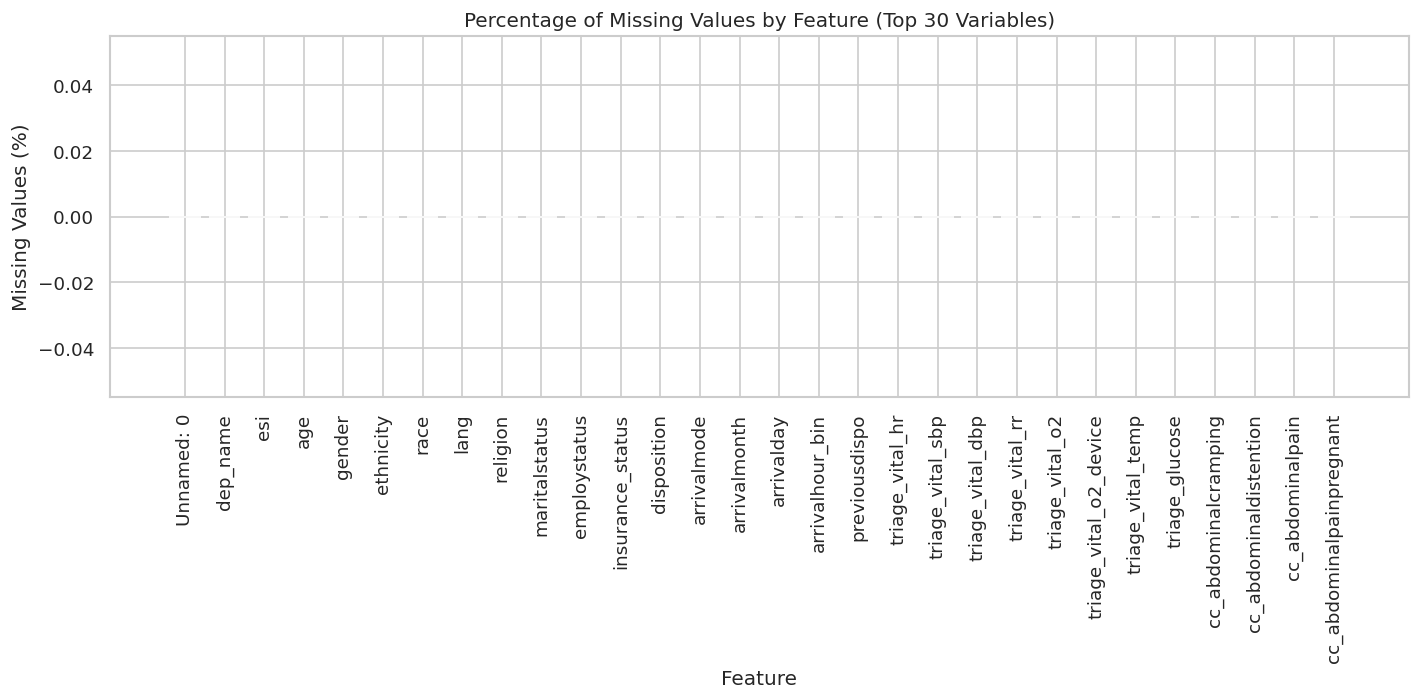

In [13]:
top_missing = missing.head(30)

plt.figure(figsize=(12, 6))

plt.bar(
    top_missing.index,
    top_missing["Missing (%)"]
)

plt.xticks(rotation=90)

plt.ylabel("Missing Values (%)")

plt.xlabel("Feature")

plt.title("Percentage of Missing Values by Feature (Top 30 Variables)")

plt.tight_layout()

plt.show()

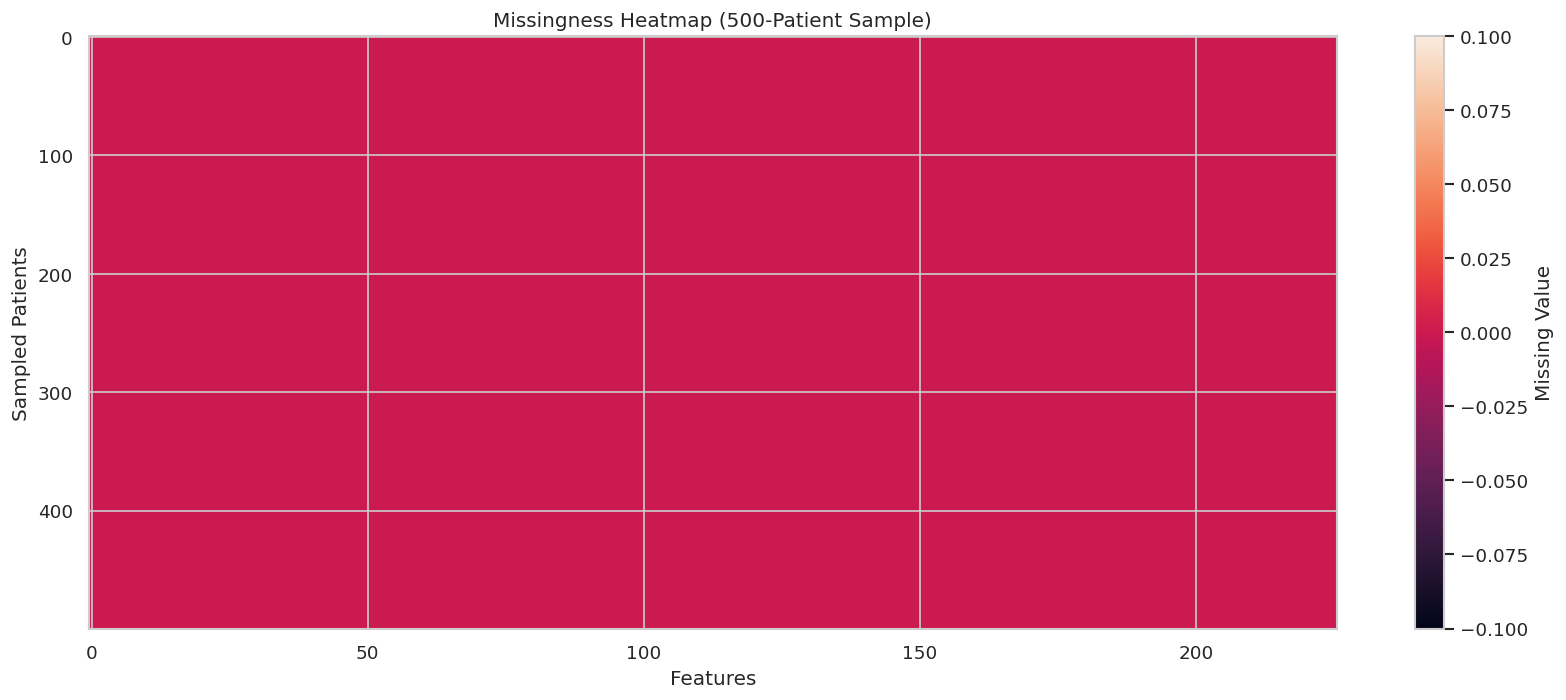

In [15]:
sample = df.sample(min(500, len(df)), random_state=42)

plt.figure(figsize=(14, 6))

plt.imshow(
    sample.isna(),
    aspect="auto",
    interpolation="nearest"
)

plt.xlabel("Features")

plt.ylabel("Sampled Patients")

plt.title("Missingness Heatmap (500-Patient Sample)")

plt.colorbar(label="Missing Value")

plt.tight_layout()

plt.show()

In [16]:
print("Current data types\n")
display(df.dtypes.value_counts())

dtype_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str)
})

display(dtype_summary.head(25))

Current data types



,count
float64,210
object,15
int64,1


,Feature,Data Type
Unnamed: 0,Unnamed: 0,int64
dep_name,dep_name,object
esi,esi,float64
age,age,float64
gender,gender,object
ethnicity,ethnicity,object
race,race,object
lang,lang,object
religion,religion,object
maritalstatus,maritalstatus,object


In [17]:
if "Unnamed: 0" in df.columns:
    df.drop(columns="Unnamed: 0", inplace=True)
    print("Removed redundant index column.")

Removed redundant index column.


In [18]:
categorical_columns = [

    "dep_name",
    "gender",
    "ethnicity",
    "race",
    "lang",
    "religion",
    "maritalstatus",
    "employstatus",
    "insurance_status",
    "disposition",
    "arrivalmode",
    "arrivalmonth",
    "arrivalday",
    "arrivalhour_bin",
    "previousdispo"

]

for col in categorical_columns:

    if col in df.columns:
        df[col] = df[col].astype("category")

print("Updated data types\n")

display(df.dtypes.value_counts())

Updated data types



,count
float64,210
category,1
category,1
category,1
category,1
category,1
category,1
category,1
category,1
category,1


In [19]:
vital_signs = [

    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp"

]

In [20]:
outlier_results = []

for feature in vital_signs:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower) | (df[feature] > upper)]

    outlier_results.append({

        "Feature": feature,
        "Lower Bound": round(lower,2),
        "Upper Bound": round(upper,2),
        "Outliers": len(outliers),
        "Percentage": round(len(outliers)/len(df)*100,2)

    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary)

,Feature,Lower Bound,Upper Bound,Outliers,Percentage
0,triage_vital_hr,39.50,131.50,578,1.05
1,triage_vital_sbp,74.50,190.50,1028,1.86
2,triage_vital_dbp,41.50,117.50,726,1.32
3,triage_vital_rr,13.00,21.00,2366,4.29
4,triage_vital_o2,93.00,101.00,1505,2.73
5,triage_vital_temp,96.65,99.45,3554,6.45


In [21]:
clinical_limits = {

    "triage_vital_hr": (20,220),
    "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200),
    "triage_vital_rr": (5,80),
    "triage_vital_o2": (50,100),
    "triage_vital_temp": (30,45)

}

physiology_results = []

for feature,(minimum,maximum) in clinical_limits.items():

    implausible = ((df[feature] < minimum) |
                   (df[feature] > maximum)).sum()

    physiology_results.append({

        "Feature": feature,
        "Physiologically Implausible Values": implausible

    })

display(pd.DataFrame(physiology_results))

,Feature,Physiologically Implausible Values
0,triage_vital_hr,1
1,triage_vital_sbp,0
2,triage_vital_dbp,0
3,triage_vital_rr,0
4,triage_vital_o2,0
5,triage_vital_temp,55121


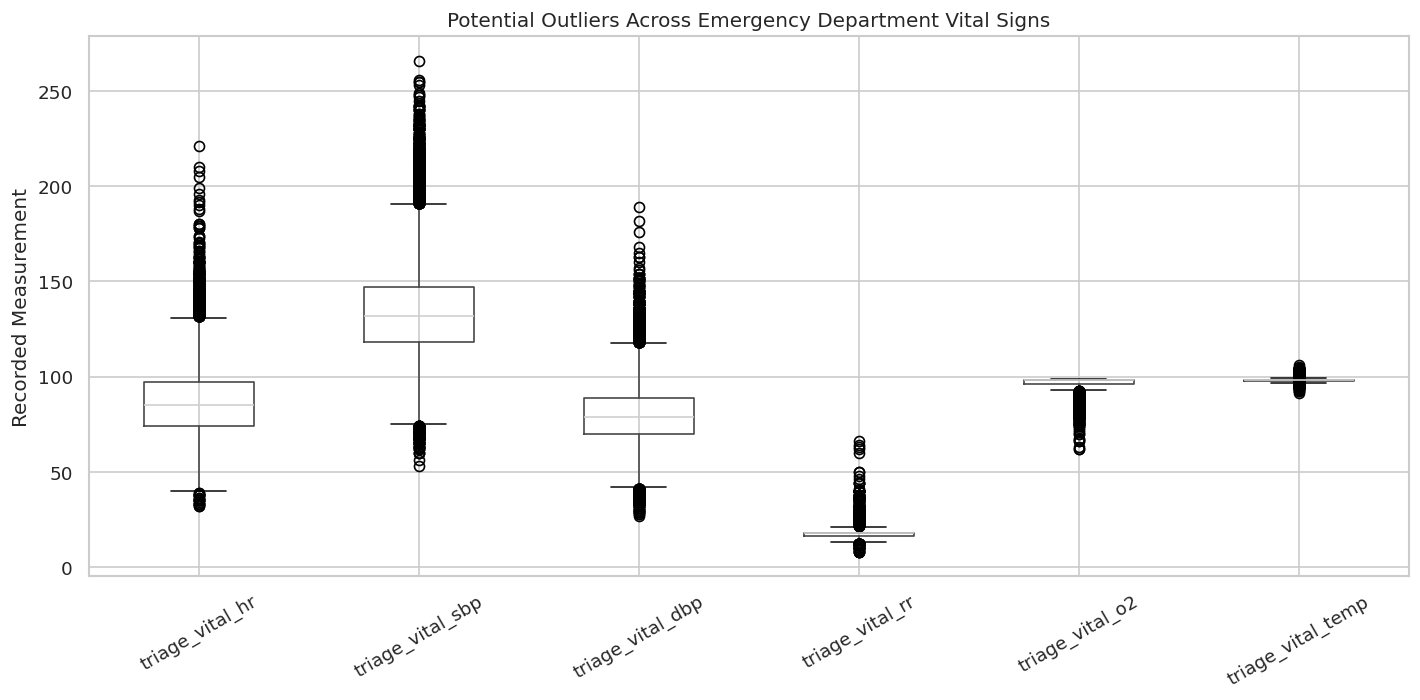

In [22]:
plt.figure(figsize=(12,6))

df[vital_signs].boxplot()

plt.title("Potential Outliers Across Emergency Department Vital Signs")

plt.ylabel("Recorded Measurement")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

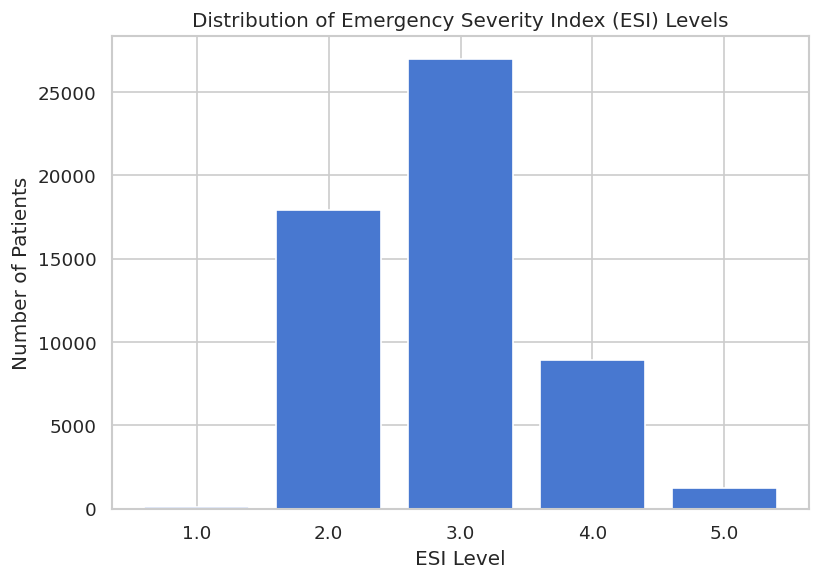

,count
esi,
1.0,77
2.0,17924
3.0,27010
4.0,8896
5.0,1214


In [24]:
esi_counts = df["esi"].value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.bar(esi_counts.index.astype(str), esi_counts.values)

plt.title("Distribution of Emergency Severity Index (ESI) Levels")
plt.xlabel("ESI Level")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.show()

display(esi_counts)

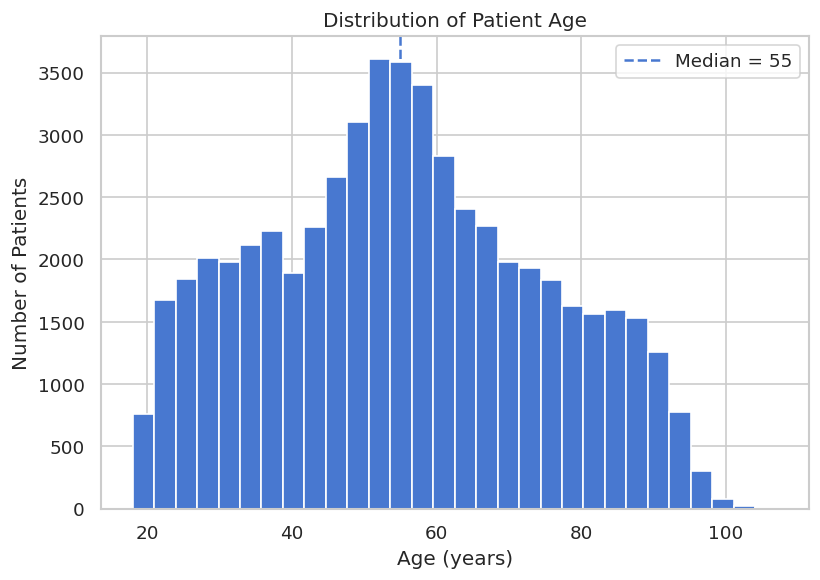

In [25]:
plt.figure(figsize=(7,5))

plt.hist(df["age"], bins=30)

plt.title("Distribution of Patient Age")
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")

plt.axvline(
    df["age"].median(),
    linestyle="--",
    label=f"Median = {df['age'].median():.0f}"
)

plt.legend()

plt.tight_layout()

plt.show()

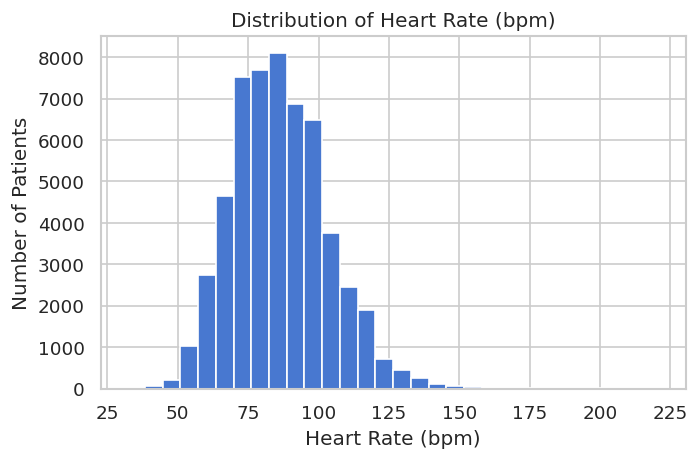

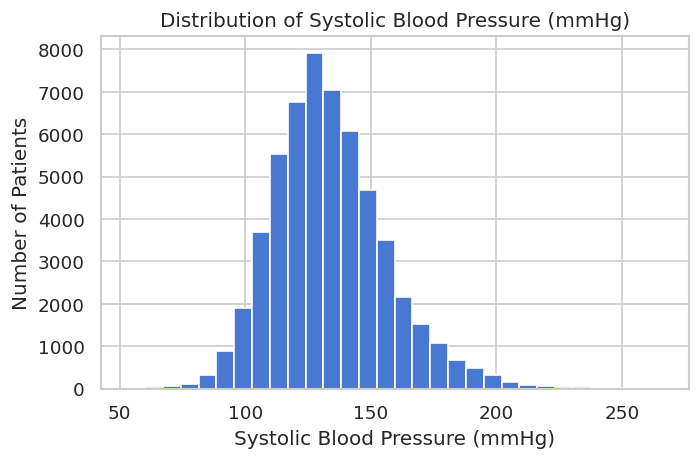

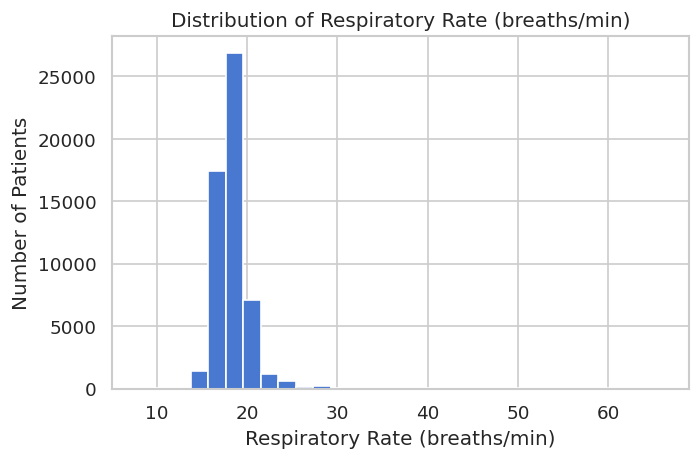

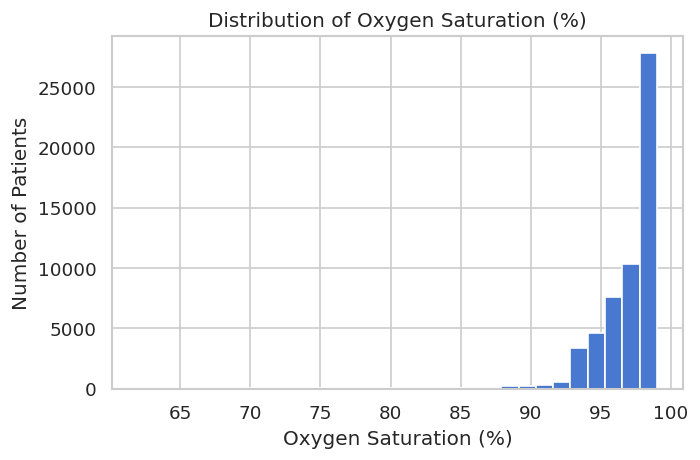

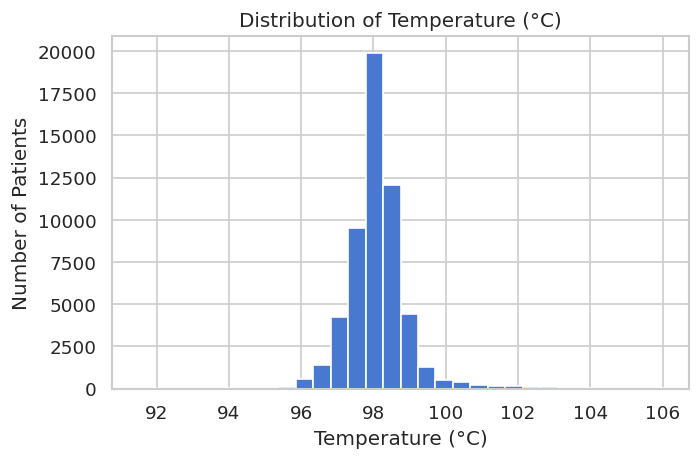

In [26]:
vital_features = [
    ("triage_vital_hr", "Heart Rate (bpm)"),
    ("triage_vital_sbp", "Systolic Blood Pressure (mmHg)"),
    ("triage_vital_rr", "Respiratory Rate (breaths/min)"),
    ("triage_vital_o2", "Oxygen Saturation (%)"),
    ("triage_vital_temp", "Temperature (°C)")
]

for feature, xlabel in vital_features:

    plt.figure(figsize=(6,4))

    plt.hist(df[feature].dropna(), bins=30)

    plt.title(f"Distribution of {xlabel}")

    plt.xlabel(xlabel)

    plt.ylabel("Number of Patients")

    plt.tight_layout()

    plt.show()

<Figure size 960x600 with 0 Axes>

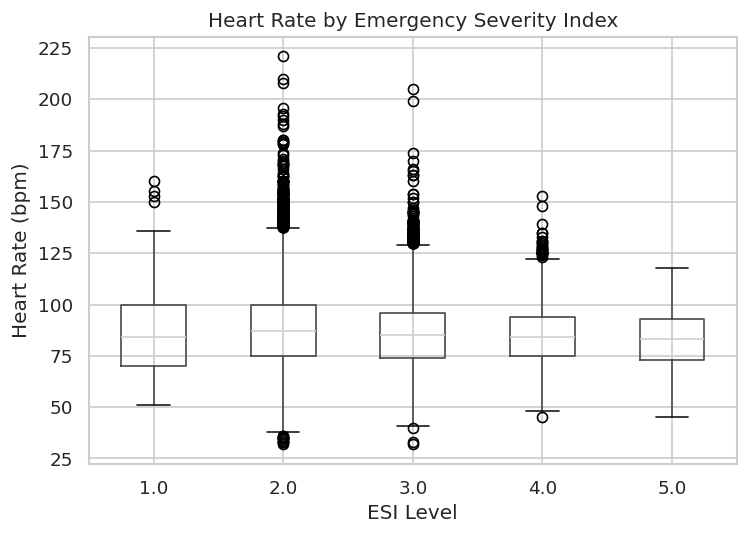

In [27]:
plt.figure(figsize=(8,5))

df.boxplot(column="triage_vital_hr", by="esi")

plt.suptitle("")

plt.title("Heart Rate by Emergency Severity Index")

plt.xlabel("ESI Level")

plt.ylabel("Heart Rate (bpm)")

plt.tight_layout()

plt.show()

<Figure size 960x600 with 0 Axes>

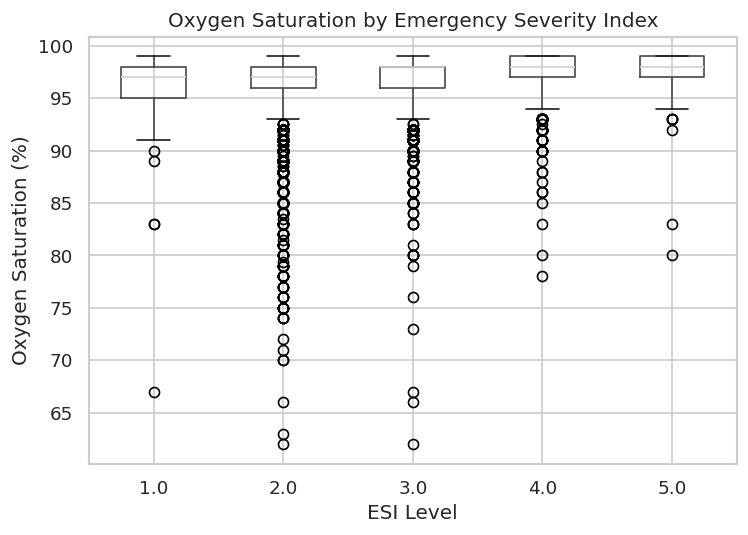

In [28]:
plt.figure(figsize=(8,5))

df.boxplot(column="triage_vital_o2", by="esi")

plt.suptitle("")

plt.title("Oxygen Saturation by Emergency Severity Index")

plt.xlabel("ESI Level")

plt.ylabel("Oxygen Saturation (%)")

plt.tight_layout()

plt.show()

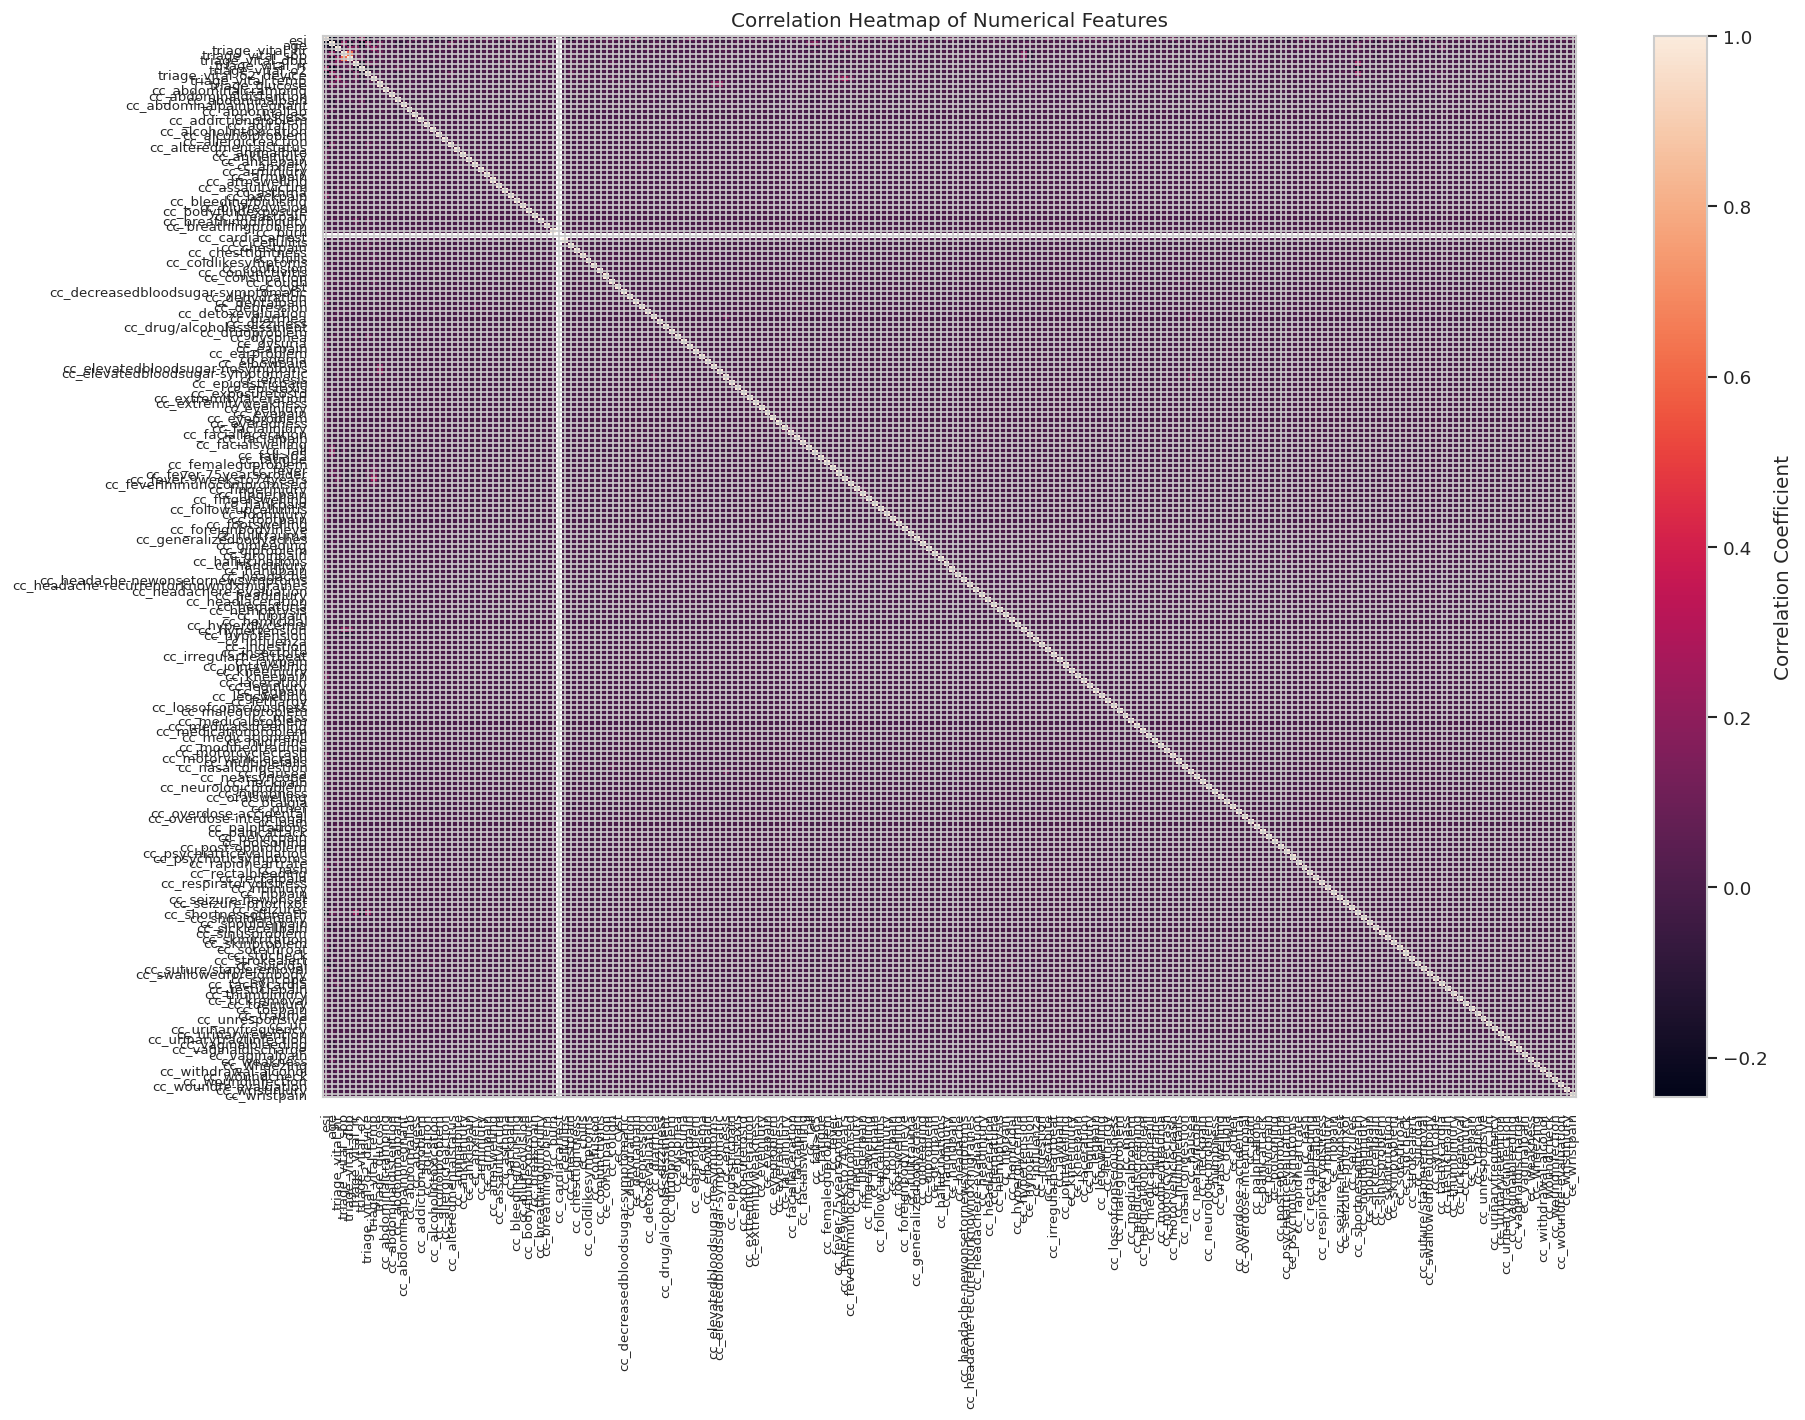

In [32]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(16,12))

plt.imshow(corr, aspect="auto")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=8)

plt.yticks(range(len(corr.columns)), corr.columns, fontsize=8)

plt.colorbar(label="Correlation Coefficient")

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()

plt.show()

In [31]:
esi_corr = (
    corr["esi"]
    .drop("esi")
    .sort_values(key=abs, ascending=False)
)

print("Top 10 Features Correlated with ESI")

display(esi_corr.head(10))

Top 10 Features Correlated with ESI


,esi
age,-0.236582
triage_vital_o2_device,-0.208956
triage_vital_o2,0.177859
cc_chestpain,-0.164328
cc_shortnessofbreath,-0.150285
cc_suicidal,-0.142603
cc_backpain,0.142140
cc_alcoholintoxication,-0.142127
cc_rash,0.133698
cc_alteredmentalstatus,-0.131958


# Overall Clinical Interpretation

The exploratory analysis indicates that the Yale EMMLC Emergency Department dataset provides a strong foundation for developing an AI-assisted triage model. The dataset contains a large number of clinically relevant variables, including demographics, vital signs, historical healthcare utilisation, and binary-encoded chief complaints that are routinely available during emergency department triage.

Several important findings emerged during the exploration. The released dataset contains minimal observable missing data, suggesting that substantial preprocessing occurred before publication. While this improves usability, it limits assessment of the original missing-data mechanisms. Outlier analysis identified several extreme physiological observations, many of which are clinically plausible in emergency medicine and should therefore be retained unless confirmed as recording errors.

The distribution of Emergency Severity Index (ESI) levels demonstrates class imbalance, with comparatively few patients assigned to the highest-acuity categories. This should be addressed during predictive modelling through appropriate sampling or class-weighting strategies to ensure that critically ill patients are represented adequately.

Correlation analysis showed that several physiological measurements exhibit meaningful relationships with triage acuity, supporting their inclusion in future predictive models. However, these associations should be interpreted as indicators of potential predictive value rather than evidence of causal relationships.

# Feasibility Assessment

## Strengths

- The dataset contains more than half a million emergency department visits, providing sufficient observations for robust model development.
- Physiological measurements collected during triage demonstrate clinically plausible relationships with Emergency Severity Index (ESI) levels.
- Variables cover multiple domains, including demographics, vital signs, healthcare utilisation, and chief complaints, allowing comprehensive modelling.
- The dataset has undergone extensive preprocessing, resulting in high overall completeness.

## Limitations

- The dataset originates from a single academic healthcare system in the United States and may not generalise directly to Mercer General Hospital without external validation.
- The released version of the dataset prevents assessment of the original missing-data patterns.
- Emergency Severity Index classes are imbalanced, particularly for the highest-acuity patients.
- Certain demographic variables may encode socioeconomic information and therefore require careful consideration during model development to minimise unintended bias.

## Overall Verdict

Based on the exploratory analysis, the Yale EMMLC dataset is suitable for AI-assisted emergency department triage modelling. Future work should focus on feature engineering, class imbalance mitigation, fairness assessment, and external validation before any clinical implementation.

In [33]:
print("=" * 70)
print("WEEK 5 EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 70)

print(f"Dataset size: {df.shape[0]:,} rows × {df.shape[1]} columns")

print(f"Numeric features: {len(df.select_dtypes(include=np.number).columns)}")
print(f"Categorical features: {len(df.select_dtypes(exclude=np.number).columns)}")

print(f"Total missing values: {int(df.isna().sum().sum()):,}")

print("\nTarget distribution:")

display(df["esi"].value_counts().sort_index())

print("\nTop correlations with ESI:")

display(esi_corr.head(10))

WEEK 5 EXPLORATORY DATA ANALYSIS SUMMARY
Dataset size: 55,121 rows × 225 columns
Numeric features: 210
Categorical features: 15
Total missing values: 0

Target distribution:


,count
esi,
1.0,77
2.0,17924
3.0,27010
4.0,8896
5.0,1214



Top correlations with ESI:


,esi
age,-0.236582
triage_vital_o2_device,-0.208956
triage_vital_o2,0.177859
cc_chestpain,-0.164328
cc_shortnessofbreath,-0.150285
cc_suicidal,-0.142603
cc_backpain,0.142140
cc_alcoholintoxication,-0.142127
cc_rash,0.133698
cc_alteredmentalstatus,-0.131958
